<a href="https://www.kaggle.com/code/anuragg25ait2017/mlops-group-project?scriptVersionId=326129221" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# MLOps Group Project: NER Fine-tuning

This notebook completes the Named Entity Recognition (NER) fine-tuning workflow for the `mlops-group-project`.

We use the Hugging Face `open-ner-english` dataset and fine-tune `dslim/bert-base-NER` for token classification.


In [17]:
!pip install -q transformers torch accelerate datasets wandb huggingface_hub scikit-learn seaborn matplotlib seqeval evaluate python-dotenv



In [18]:
!pip install sentencepiece tiktoken


In [19]:

## **Step 1 — Load credentials from Kaggle Secrets**
import os
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
os.environ["WANDB_API_KEY"] = secrets.get_secret("WANDB_API_KEY")
os.environ["HF_TOKEN"]      = secrets.get_secret("HF_TOKEN")

print("Secrets loaded.")

# import dotenv
# dotenv.load_dotenv()

Secrets loaded.


In [20]:
import os
import random
from datetime import datetime

import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)
from sklearn.metrics import classification_report, confusion_matrix
import wandb
import evaluate

sns.set(style='ticks', font_scale=1.2)

# ── Reproducibility 
SEED = int(os.getenv('SEED', '42'))
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ── Device 
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'Using device: {device}')

models={
    '0': 'dslim/bert-base-NER',
    '1': 'elastic/distilbert-base-uncased-finetuned-conll03-english',
    '2': 'microsoft/deberta-v3-base'
}

# ── Model / data 
MODEL_NAME   = os.getenv('MODEL_NAME', models.get('0'))
# MODEL_NAME   = os.getenv('MODEL_NAME',   'dslim/bert-base-NER')
MAX_LENGTH   = int(os.getenv('MAX_LENGTH', '256'))
DATASET_NAME = os.getenv('DATASET_NAME', 'yongsun-yoon/open-ner-english')

# ── Paths 
ARTIFACTS_DIR               = os.getenv('ARTIFACTS_DIR', './artifacts')
OUTPUT_DIR                  = os.getenv('OUTPUT_DIR',     './ner_results')
LOCAL_MODEL_DIR             = os.getenv('LOCAL_MODEL_DIR', f'./models/{MODEL_NAME.replace("/", "-")}')
EVAL_OUTPUT_DIR             = os.path.join(ARTIFACTS_DIR, 'eval_results')
DATASET_PICKLE_PATH         = os.getenv('DATASET_PICKLE_PATH',         os.path.join(ARTIFACTS_DIR, 'open_ner_english_dataset.pkl'))
CLEANED_DATASET_PICKLE_PATH = os.getenv('CLEANED_DATASET_PICKLE_PATH', os.path.join(ARTIFACTS_DIR, 'open_ner_english_cleaned.pkl'))
PROCESSED_DATA_FILE         = os.getenv('PROCESSED_DATA_FILE',         os.path.join(ARTIFACTS_DIR, 'processed_ner_data.pkl'))
ID2LABEL_FILE               = os.getenv('ID2LABEL_FILE',               os.path.join(ARTIFACTS_DIR, 'id2label.json'))

for _d in [ARTIFACTS_DIR, OUTPUT_DIR, EVAL_OUTPUT_DIR]:
    os.makedirs(_d, exist_ok=True)

# ── Subset controls
# Increased from 2000/400 → more data = better generalisation
# Reduced MAX_ENTITY_TYPES from 512 → fewer, denser labels = higher precision
USE_SUBSET              = True
TRAIN_MAX_SAMPLES       = int(os.getenv('TRAIN_MAX_SAMPLES',       '2000'))   
VALIDATION_MAX_SAMPLES  = int(os.getenv('VALIDATION_MAX_SAMPLES',  '400'))   
MAX_ENTITY_TYPES        = int(os.getenv('MAX_ENTITY_TYPES',        '100'))     
RARE_ENTITY_POLICY      = os.getenv('RARE_ENTITY_POLICY', 'O').upper()
TOP_K_CONFUSION         = int(os.getenv('TOP_K_CONFUSION', '15'))

# ── W&B / HF 
ENABLE_WANDB   = True
WANDB_PROJECT  = os.getenv('WANDB_PROJECT',  'mlops-group-project')
WANDB_RUN_NAME = os.getenv('WANDB_RUN_NAME', f'ner-fine-tune-run-{MODEL_NAME.replace("/", "-")}')
WANDB_RUN_NAME = f"{WANDB_RUN_NAME}-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
HF_TOKEN       = os.getenv('HF_TOKEN')
HF_REPO        = os.getenv('HF_REPO', 'anuragvishwakarma02/mlops-group23-ner')



# ── Training hyper-parameters
# V1

LEARNING_RATE       = float(os.getenv('LEARNING_RATE',     '3e-5'))
TRAIN_BATCH_SIZE    = int(os.getenv('TRAIN_BATCH_SIZE',    '16' if device != 'cpu' else '8'))
EVAL_BATCH_SIZE     = int(os.getenv('EVAL_BATCH_SIZE',     '16' if device != 'cpu' else '8'))
NUM_TRAIN_EPOCHS    = float(os.getenv('NUM_TRAIN_EPOCHS',  '3'))    
WEIGHT_DECAY        = float(os.getenv('WEIGHT_DECAY',      '0.01'))
WARMUP_RATIO        = float(os.getenv('WARMUP_RATIO',      '0.1')) 
LOGGING_STEPS       = int(os.getenv('LOGGING_STEPS',       '50'))

# # V2
# ## Lower LR + warmup ratio + more epochs -> slower, more stable convergence
# LEARNING_RATE       = float(os.getenv('LEARNING_RATE',     '5e-5'))   
# TRAIN_BATCH_SIZE    = int(os.getenv('TRAIN_BATCH_SIZE',    '16' if device != 'cpu' else '8'))
# EVAL_BATCH_SIZE     = int(os.getenv('EVAL_BATCH_SIZE',     '16' if device != 'cpu' else '8'))
# NUM_TRAIN_EPOCHS    = float(os.getenv('NUM_TRAIN_EPOCHS',  '5'))       
# WEIGHT_DECAY        = float(os.getenv('WEIGHT_DECAY',      '0.01'))
# WARMUP_RATIO        = float(os.getenv('WARMUP_RATIO',      '0.1'))    
# LOGGING_STEPS       = int(os.getenv('LOGGING_STEPS',       '50'))

Using device: cuda


## 1. Dataset load and sanity checks

Load the English NER dataset and inspect its structure before tokenizing.


In [21]:
import pickle

def load_dataset_with_cache():
    os.makedirs(os.path.dirname(DATASET_PICKLE_PATH), exist_ok=True)
    try:
        if os.path.exists(DATASET_PICKLE_PATH):
            with open(DATASET_PICKLE_PATH, 'rb') as f:
                ds = pickle.load(f)
            print(f'[data] Loaded dataset from pickle: {DATASET_PICKLE_PATH}')
        else:
            ds = load_dataset(DATASET_NAME)
            with open(DATASET_PICKLE_PATH, 'wb') as f:
                pickle.dump(ds, f)
            print(f'[data] Downloaded dataset from Hugging Face Hub: {DATASET_NAME}')
    except Exception:
        ds = load_dataset(DATASET_NAME)
        with open(DATASET_PICKLE_PATH, 'wb') as f:
            pickle.dump(ds, f)
        print('[data] Cache load failed; downloaded fresh copy.')
    return ds

dataset = load_dataset_with_cache()

# ── Subset ───────────────────────────────────────────────────────────────────
if USE_SUBSET:
    for split_name, max_n in [('train', TRAIN_MAX_SAMPLES), ('validation', VALIDATION_MAX_SAMPLES)]:
        if split_name in dataset and max_n > 0:
            n = min(max_n, len(dataset[split_name]))
            dataset[split_name] = dataset[split_name].shuffle(seed=SEED).select(range(n))
            print(f'[data] Subset applied -> {split_name}: {n} rows')

print(dataset)
print('Train features:')
print(dataset['train'].features)
print('Sample train item (text):')
print(dataset['train'][0].get('text', '')[:200])


[data] Loaded dataset from pickle: ./artifacts/open_ner_english_dataset.pkl
[data] Subset applied -> train: 5000 rows
[data] Subset applied -> validation: 1000 rows
DatasetDict({
    train: Dataset({
        features: ['text', 'entities'],
        num_rows: 5000
    })
    validation: Dataset({
        features: ['text', 'entities'],
        num_rows: 1000
    })
})
Train features:
{'text': Value('string'), 'entities': List({'entity_mentions': List(Value('string')), 'entity_type': Value('string')})}
Sample train item (text):
Friday, April 29, 2011

Land of Misfit Gadgets - what to do? The launch of the iPad2 marked the biggest event in reCommerce history. After receiving a record 13k iPads, Gazelle, a site only known for 


## 2. Data cleaning

In [22]:
import re
import pickle

# ── Regex patterns (compiled once) 
FRONT_MATTER_RE = re.compile(r'^---[\s\S]*?---\s*')
CITATION_RE     = re.compile(r"\[@[^\]]+\]")
SECTION_TAG_RE  = re.compile(r"\{#section[^}]*\}")
LATEX_CMD_RE    = re.compile(r"\\[A-Za-z]+")
NON_ALNUM_RE    = re.compile(r"[^A-Za-z0-9\s]+")
MULTISPACE_RE   = re.compile(r"\s+")

def strip_special_chars(text):
    if text is None:
        return ''
    text = str(text).replace('\\r\\n', ' ').replace('\\n', ' ').replace('\\r', ' ').replace('\\xa0', ' ')
    text = FRONT_MATTER_RE.sub(' ', text)
    text = CITATION_RE.sub(' ', text)
    text = SECTION_TAG_RE.sub(' ', text)
    text = LATEX_CMD_RE.sub(' ', text)
    text = NON_ALNUM_RE.sub(' ', text)
    text = MULTISPACE_RE.sub(' ', text).strip()
    # NOTE: Do NOT lowercase — dslim/bert-base-NER is a cased model;
    # capitalization is a critical signal for NER (e.g. "London" vs "london").
    return text

def clean_entities_for_ner(entities):
    cleaned = []
    if not isinstance(entities, list):
        return cleaned
    for entity in entities:
        if not isinstance(entity, dict):
            continue
        entity_type = entity.get('entity_type', entity.get('type', entity.get('label')))
        mentions = entity.get('entity_mentions', [])
        if isinstance(mentions, list):
            cleaned_mentions = [strip_special_chars(m) for m in mentions if strip_special_chars(m)]
            if cleaned_mentions and entity_type is not None:
                cleaned.append({'entity_mentions': cleaned_mentions, 'entity_type': entity_type})
        else:
            cleaned.append(entity)
    return cleaned

def clean_example(example):
    example['raw_text'] = example.get('text', '')
    example['text']     = strip_special_chars(example.get('text', ''))
    example['entities'] = clean_entities_for_ner(example.get('entities', []))
    return example

dataset = dataset.map(clean_example, load_from_cache_file=False)

# ── VALIDATION: post-cleaning 
print('=' * 60)
print('STEP 1.1 – Data preparation: post-clean validation')
print('=' * 60)
for split_name in dataset.keys():
    n           = len(dataset[split_name])
    empty_texts = sum(1 for r in dataset[split_name] if not r.get('text', '').strip())
    total_ents  = sum(len(r.get('entities', [])) for r in dataset[split_name])
    print(f'[validate-clean] {split_name}: {n} rows | {empty_texts} empty texts | {total_ents} entity annotations')

# ── CLEAN STEP 1: drop empty-text rows 
print('\n[clean-step-1] Dropping rows with empty text...')
for split_name in dataset.keys():
    before = len(dataset[split_name])
    dataset[split_name] = dataset[split_name].filter(
        lambda r: bool(r.get('text', '').strip()), load_from_cache_file=False
    )
    after = len(dataset[split_name])
    print(f'  {split_name}: {before} -> {after} rows (dropped {before - after})')

with open(CLEANED_DATASET_PICKLE_PATH, 'wb') as f:
    pickle.dump(dataset, f)
print(f'\nSaved cleaned dataset: {CLEANED_DATASET_PICKLE_PATH}')
print('Sample cleaned text:', dataset['train'][0]['text'][:300])
print('Sample cleaned entities:', dataset['train'][0]['entities'][:2])


Map: 100%|##########| 5000/5000 [00:00<?, ? examples/s]

Map: 100%|##########| 1000/1000 [00:00<?, ? examples/s]

STEP 1.1 – Data preparation: post-clean validation
[validate-clean] train: 5000 rows | 5 empty texts | 25872 entity annotations
[validate-clean] validation: 1000 rows | 1 empty texts | 5329 entity annotations

[clean-step-1] Dropping rows with empty text...


Filter: 100%|##########| 5000/5000 [00:00<?, ? examples/s]

  train: 5000 -> 4995 rows (dropped 5)


Filter: 100%|##########| 1000/1000 [00:00<?, ? examples/s]

  validation: 1000 -> 999 rows (dropped 1)

Saved cleaned dataset: ./artifacts/open_ner_english_cleaned.pkl
Sample cleaned text: Friday April 29 2011 Land of Misfit Gadgets what to do The launch of the iPad2 marked the biggest event in reCommerce history After receiving a record 13k iPads Gazelle a site only known for only taking used gadgets has made the first move to resale opening www gazelleipads com a first in the compan
Sample cleaned entities: [{'entity_mentions': ['www gazelleipads com'], 'entity_type': 'URL'}, {'entity_mentions': ['Friday April 29 2011'], 'entity_type': 'DATE'}]


In [23]:
# print(dataset['train'][:5])

## 2. Label schema and split selection

Infer token and label columns, build label mappings, and choose the evaluation split.

This step follows the label-schema preparation
- converting text/entities into token-level BIO tags when needed,
- collapsing rare entity types (optional),
- building a stable label mapping (`ordered_tags`, `label2id`, `id2label`) across splits, and
- detecting token/label columns plus evaluation split selection.

How entities can look in raw data:
- Span schema: `{'start': 10, 'end': 22, 'label': 'ORG'}`
- Mention schema: `{'entity_mentions': ['microsoft', 'google'], 'entity_type': 'ORG'}`

How extraction works:
- Text is split into tokens with character spans using regex (`\S+`).
- For each entity, spans are collected from either explicit offsets or mention-string matches.
- Each entity span is matched to overlapping token spans.
- BIO tags are assigned: first matched token gets `B-<TYPE>`, following tokens get `I-<TYPE>`.
- If a token is already labeled, existing non-`O` labels are preserved to avoid overwriting.


In [24]:
import json
from collections import Counter

# ── BIO-tag helpers 
def build_tokens_with_spans(text):
    tokens, spans = [], []
    for m in re.finditer(r'\S+', text):
        tokens.append(m.group(0))
        spans.append((m.start(), m.end()))
    return tokens, spans

def find_all_occurrences(text, phrase):
    if not phrase:
        return []
    return [(m.start(), m.end()) for m in re.finditer(re.escape(phrase), text)]

def normalize_label(label):
    if label is None:
        return None
    norm = str(label).strip().upper().replace(' ', '_')
    norm = re.sub(r'[^A-Z0-9_\-]', '_', norm)
    norm = re.sub(r'_+', '_', norm).strip('_')
    return norm or None

def split_bio_tag(tag):
    if not isinstance(tag, str) or tag == 'O' or '-' not in tag:
        return None, None
    prefix, entity_type = tag.split('-', 1)
    if prefix not in {'B', 'I'} or not entity_type:
        return None, None
    return prefix, entity_type

def get_entity_spans(entity, text):
    spans = []
    if not isinstance(entity, dict):
        return spans
    start = entity.get('start', entity.get('start_offset', entity.get('begin_offset')))
    end   = entity.get('end',   entity.get('end_offset',   entity.get('stop_offset')))
    label = entity.get('label', entity.get('type', entity.get('entity', entity.get('tag'))))
    if start is not None and end is not None and label is not None:
        try:
            s, e = int(start), int(end)
            norm = normalize_label(label)
            if s < e and norm:
                spans.append((s, e, norm))
        except Exception:
            pass
    mentions    = entity.get('entity_mentions', [])
    entity_type = normalize_label(entity.get('entity_type', label))
    if isinstance(mentions, list) and entity_type:
        for mention in mentions:
            if isinstance(mention, str):
                for s, e in find_all_occurrences(text, mention):
                    spans.append((s, e, entity_type))
    return spans

def convert_text_entities_to_tokens_tags(example):
    text     = example.get('text', '')
    entities = example.get('entities', [])
    tokens, token_spans = build_tokens_with_spans(text)
    tags = ['O'] * len(tokens)
    all_spans = [span for entity in entities for span in get_entity_spans(entity, text)]
    for start, end, label in all_spans:
        idxs = [i for i, (ts, te) in enumerate(token_spans) if te > start and ts < end]
        if not idxs:
            continue
        if tags[idxs[0]] == 'O':
            tags[idxs[0]] = f'B-{label}'
        for idx in idxs[1:]:
            if tags[idx] == 'O':
                tags[idx] = f'I-{label}'
    example['tokens']       = tokens
    example['ner_str_tags'] = tags
    return example

def collapse_rare_entity_types(example, keep_types, rare_entity_policy='O'):
    collapsed = []
    for tag in example['ner_str_tags']:
        if tag == 'O':
            collapsed.append('O')
            continue
        prefix, entity_type = split_bio_tag(tag)
        if prefix is None:
            collapsed.append('O')
            continue
        if entity_type in keep_types:
            collapsed.append(tag)
        elif rare_entity_policy == 'MISC':
            collapsed.append(f'{prefix}-MISC')
        else:
            collapsed.append('O')
    example['ner_str_tags'] = collapsed
    return example

# ── Convert text/entities -> tokens/ner_tags 
already_has_labels = (
    'tokens' in dataset['train'].column_names and (
        'ner_tags' in dataset['train'].column_names or
        'tags'     in dataset['train'].column_names
    )
)

if not already_has_labels:
    dataset = dataset.map(convert_text_entities_to_tokens_tags, load_from_cache_file=False)

    type_counter = Counter()
    for split_name in dataset.keys():
        for row in dataset[split_name]['ner_str_tags']:
            for tag in row:
                _, et = split_bio_tag(tag)
                if et:
                    type_counter[et] += 1

    if len(type_counter) > MAX_ENTITY_TYPES:
        keep_types = {et for et, _ in type_counter.most_common(MAX_ENTITY_TYPES)}
        dataset = dataset.map(
            lambda ex: collapse_rare_entity_types(ex, keep_types, RARE_ENTITY_POLICY),
            load_from_cache_file=False,
        )
        print(f'Collapsed rare entity types: kept top {MAX_ENTITY_TYPES} of {len(type_counter)} (policy={RARE_ENTITY_POLICY})')

    unique_tag_set = {'O'}
    for split_name in dataset.keys():
        for row in dataset[split_name]['ner_str_tags']:
            unique_tag_set.update(row)

    ordered_tags = ['O'] + sorted(t for t in unique_tag_set if t != 'O')
    str2id = {tag: i for i, tag in enumerate(ordered_tags)}

    def str_tags_to_ids(example):
        example['ner_tags'] = [str2id[t] for t in example['ner_str_tags']]
        return example

    dataset = dataset.map(str_tags_to_ids, load_from_cache_file=False)

    # ── VALIDATION 2: post token/tag conversion 
    print('=' * 60)
    print('STEP 1.2 – Post-conversion validation')
    print('=' * 60)
    for split_name in dataset.keys():
        rows         = dataset[split_name]
        empty_tokens = sum(1 for r in rows if len(r.get('tokens', [])) == 0)
        all_o        = sum(1 for r in rows if r.get('ner_str_tags') and all(t == 'O' for t in r['ner_str_tags']))
        has_ents     = sum(1 for r in rows if any(t != 'O' for t in r.get('ner_str_tags', [])))
        print(f'[validate-convert] {split_name}: {empty_tokens} empty-token rows | {all_o} all-O rows | {has_ents} rows with entities')

    # ── CLEAN STEP 2: drop empty-token rows 
    for split_name in dataset.keys():
        before = len(dataset[split_name])
        dataset[split_name] = dataset[split_name].filter(
            lambda r: len(r.get('tokens', [])) > 0, load_from_cache_file=False
        )
        print(f'[clean-step-2] {split_name}: {before} -> {len(dataset[split_name])} rows')

    print('Converted dataset from text/entities to tokens/ner_tags format.')
else:
    print('Dataset already has token-level labels.')
    lf = dataset['train'].features.get('ner_tags', dataset['train'].features.get('tags'))
    ordered_tags = list(lf.feature.names) if hasattr(lf.feature, 'names') else [str(i) for i in sorted({l for s in dataset.keys() for row in dataset[s]['ner_tags'] for l in row})]

# ── Column detection + label mapping 
def detect_columns(ds_split):
    token_col = 'tokens' if 'tokens' in ds_split.column_names else 'words'
    if 'ner_tags' in ds_split.column_names:
        label_col = 'ner_tags'
    elif 'tags' in ds_split.column_names:
        label_col = 'tags'
    else:
        raise ValueError(f'No label column in: {ds_split.column_names}')
    return token_col, label_col

token_col, label_col = detect_columns(dataset['train'])
label_list = list(ordered_tags)
id2label   = {i: lbl for i, lbl in enumerate(label_list)}
label2id   = {lbl: i for i, lbl in id2label.items()}
eval_split = 'validation' if 'validation' in dataset else 'test'

# ── Save id2label artifact 
with open(ID2LABEL_FILE, 'w') as f:
    json.dump({str(k): v for k, v in id2label.items()}, f, indent=2)

print(f'Token column  : {token_col}')
print(f'Label column  : {label_col}')
print(f'Num labels    : {len(label_list)}')
print(f'Labels preview: {label_list[:20]}')
print(f'Eval split    : {eval_split}')
print(f'id2label saved: {ID2LABEL_FILE}')


Map: 100%|##########| 4995/4995 [00:00<?, ? examples/s]

Map: 100%|##########| 999/999 [00:00<?, ? examples/s]

Map: 100%|##########| 4995/4995 [00:00<?, ? examples/s]

Map: 100%|##########| 999/999 [00:00<?, ? examples/s]

Collapsed rare entity types: kept top 100 of 3103 (policy=O)


...

STEP 1.2 – Post-conversion validation
[validate-convert] train: 0 empty-token rows | 199 all-O rows | 4796 rows with entities
[validate-convert] validation: 0 empty-token rows | 40 all-O rows | 959 rows with entities


Filter: 100%|##########| 4995/4995 [00:00<?, ? examples/s]

[clean-step-2] train: 4995 -> 4995 rows


Filter: 100%|##########| 999/999 [00:00<?, ? examples/s]

[clean-step-2] validation: 999 -> 999 rows
Converted dataset from text/entities to tokens/ner_tags format.
Token column  : tokens
Label column  : ner_tags
Num labels    : 201
Labels preview: ['O', 'B-ACTION', 'B-ACTIVITY', 'B-ANATOMICAL_STRUCTURE', 'B-ANATOMY', 'B-ANIMAL', 'B-ATTRIBUTE', 'B-AWARD', 'B-BIOLOGICAL_ENTITY', 'B-BIOLOGICAL_PROCESS', 'B-BODY_PART', 'B-BOOK', 'B-BRAND', 'B-CATEGORY', 'B-CELL_TYPE', 'B-CHEMICAL', 'B-CHEMICAL_COMPOUND', 'B-CITY', 'B-CLASS', 'B-COMPANY']
Eval split    : validation
id2label saved: ./artifacts/id2label.json


In [25]:
label_list

['O',
 'B-ACTION',
 'B-ACTIVITY',
 'B-ANATOMICAL_STRUCTURE',
 'B-ANATOMY',
 'B-ANIMAL',
 'B-ATTRIBUTE',
 'B-AWARD',
 'B-BIOLOGICAL_ENTITY',
 'B-BIOLOGICAL_PROCESS',
 'B-BODY_PART',
 'B-BOOK',
 'B-BRAND',
 'B-CATEGORY',
 'B-CELL_TYPE',
 'B-CHEMICAL',
 'B-CHEMICAL_COMPOUND',
 'B-CITY',
 'B-CLASS',
 'B-COMPANY',
 'B-COMPONENT',
 'B-COMPOUND',
 'B-CONCEPT',
 'B-CONDITION',
 'B-COUNTRY',
 'B-CURRENCY',
 'B-DATA',
 'B-DATA_TYPE',
 'B-DATE',
 'B-DEVICE',
 'B-DISEASE',
 'B-DOCUMENT',
 'B-DRUG',
 'B-ENTITY',
 'B-ENTITY_TYPE',
 'B-EQUIPMENT',
 'B-EVENT',
 'B-FACILITY',
 'B-FILE',
 'B-FOOD',
 'B-FUNCTION',
 'B-GENE',
 'B-GROUP',
 'B-JOB_TITLE',
 'B-LAW',
 'B-LIBRARY',
 'B-LOCATION',
 'B-MATERIAL',
 'B-MEASUREMENT',
 'B-MEDICAL_CONDITION',
 'B-MEDICAL_PROCEDURE',
 'B-MEDICAL_TEST',
 'B-MEDICAL_TREATMENT',
 'B-METHOD',
 'B-MISCELLANEOUS',
 'B-MOLECULE',
 'B-MONEY',
 'B-MOVIE',
 'B-NATIONALITY',
 'B-NUMBER',
 'B-OBJECT',
 'B-OCCUPATION',
 'B-ORGANISM',
 'B-ORGANIZATION',
 'B-OTHER',
 'B-PATENT',
 'B

## 3. Tokenization and label alignment

Convert words to subword tokens and align labels to the first token of each word (`-100` for ignored positions).

In [26]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples[token_col],
        truncation=True,
        is_split_into_words=True,
        max_length=MAX_LENGTH,
    )
    aligned_labels = []
    for batch_idx in range(len(examples[token_col])):
        word_ids  = tokenized.word_ids(batch_index=batch_idx)
        labels    = examples[label_col][batch_idx]
        label_ids = []
        prev_word_id = None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word_id:
                label_ids.append(labels[word_id])
            else:
                label_ids.append(-100)
            prev_word_id = word_id
        aligned_labels.append(label_ids)
    tokenized['labels'] = aligned_labels
    return tokenized

tokenized_dataset = dataset.map(tokenize_and_align_labels, batched=True)
print(tokenized_dataset)

# ── Guard: no out-of-range label ids 
expected_num_labels = len(label_list)
for split_name in tokenized_dataset.keys():
    max_seen = max(
        (lbl for row in tokenized_dataset[split_name]['labels'] for lbl in row if lbl != -100),
        default=-1,
    )
    print(f'{split_name}: max label id = {max_seen}, expected < {expected_num_labels}')
    if max_seen >= expected_num_labels:
        raise ValueError(
            f'Out-of-range label id in {split_name}: {max_seen} >= {expected_num_labels}. '
            'Rebuild label_list from all splits before training.'
        )


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/4995 [00:00<?, ? examples/s]

Map:   0%|          | 0/999 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'entities', 'raw_text', 'tokens', 'ner_str_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 4995
    })
    validation: Dataset({
        features: ['text', 'entities', 'raw_text', 'tokens', 'ner_str_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 999
    })
})
train: max label id = 200, expected < 201
validation: max label id = 200, expected < 201


## 4. Metrics, trainer, and fine-tuning

Set token-classification metrics, initialize Trainer, and run fine-tuning.

In [27]:
data_collator  = DataCollatorForTokenClassification(tokenizer=tokenizer)
seqeval_metric = evaluate.load('seqeval')

num_labels = len(label_list)
print(f'num_labels = {num_labels}')

def compute_metrics(eval_pred):
    """Token-classification metrics using seqeval."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=2)

    true_predictions, true_labels = [], []
    for pred_seq, label_seq in zip(predictions, labels):
        pred_tags, true_tags = [], []
        for pred_id, label_id in zip(pred_seq, label_seq):
            if label_id != -100:
                pred_tags.append(label_list[pred_id])
                true_tags.append(label_list[label_id])
        true_predictions.append(pred_tags)
        true_labels.append(true_tags)

    results = seqeval_metric.compute(predictions=true_predictions, references=true_labels)
    return {
        'precision': results['overall_precision'],
        'recall':    results['overall_recall'],
        'f1':        results['overall_f1'],
        'accuracy':  results['overall_accuracy'],
    }

print(f'Max train label id : {max(l for row in dataset["train"][label_col] for l in row)}')
print(f'Max eval  label id : {max(l for row in dataset[eval_split][label_col] for l in row)}')


num_labels = 201
Max train label id : 200
Max eval  label id : 200


In [28]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(device)

if ENABLE_WANDB:
    if os.environ.get('WANDB_API_KEY'):
        wandb.init(
            project=WANDB_PROJECT,
            name=WANDB_RUN_NAME,
            config={
                'model_name':MODEL_NAME,
                'max_length':MAX_LENGTH,
                'num_labels':num_labels,
                'epochs':NUM_TRAIN_EPOCHS,
                'train_batch_size': TRAIN_BATCH_SIZE,
                'eval_batch_size':  EVAL_BATCH_SIZE,
                'dataset':DATASET_NAME,
                'task':'token-classification',
                'seed':SEED,
            },
        )
        print(f'W&B run initialised: {WANDB_RUN_NAME}')
    else:
        print('WANDB_API_KEY not set; skipping W&B logging.')
        ENABLE_WANDB = False

# ── TrainingArguments 
training_args = TrainingArguments(
    output_dir= OUTPUT_DIR,
    learning_rate= LEARNING_RATE,
    per_device_train_batch_size = TRAIN_BATCH_SIZE,
    per_device_eval_batch_size  = EVAL_BATCH_SIZE,
    num_train_epochs= NUM_TRAIN_EPOCHS,
    weight_decay= WEIGHT_DECAY,
    eval_strategy= 'epoch',
    save_strategy= 'epoch',
    logging_strategy= 'steps',
    logging_steps= LOGGING_STEPS,
    load_best_model_at_end= True,
    metric_for_best_model= 'f1',
    report_to= ['wandb'] if ENABLE_WANDB else [],
    run_name= WANDB_RUN_NAME,
    seed= SEED,
    push_to_hub= False,
)

trainer = Trainer(
    model= model,
    args= training_args,
    train_dataset= tokenized_dataset['train'],
    eval_dataset= tokenized_dataset[eval_split],
    data_collator= data_collator,
    compute_metrics= compute_metrics,
    processing_class = tokenizer,
)

train_result = trainer.train()
print('Training finished.')
print(train_result)


model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |                                                                                       
-------------------------+------------+---------------------------------------------------------------------------------------
bert.pooler.dense.bias   | UNEXPECTED |                                                                                       
bert.pooler.dense.weight | UNEXPECTED |                                                                                       
classifier.weight        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([9, 768]) vs model:torch.Size([201, 768])
classifier.bias          | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([9]) vs model:torch.Size([201])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did n

W&B run initialised: ner-fine-tune-run-dslim-bert-base-NER-20260610-170552


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training finished.
TrainOutput(global_step=471, training_loss=1.5728280053270345, metrics={'train_runtime': 436.0565, 'train_samples_per_second': 34.365, 'train_steps_per_second': 1.08, 'total_flos': 1961242244542980.0, 'train_loss': 1.5728280053270345, 'epoch': 3.0})


## 5. Evaluation and reports

Run final evaluation, generate token-level classification report, and visualize confusion matrix.

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Evaluation results: {'eval_loss': 1.3521713018417358, 'eval_precision': 0.4493093241243217, 'eval_recall': 0.23762311656121585, 'eval_f1': 0.31084943896923933, 'eval_accuracy': 0.856782703273628, 'eval_runtime': 10.7554, 'eval_samples_per_second': 92.884, 'eval_steps_per_second': 2.975, 'epoch': 3.0}
                        precision    recall  f1-score   support

                     O     0.8858    0.9718    0.9268    132562
              B-ACTION     0.0000    0.0000    0.0000        42
            B-ACTIVITY     0.0000    0.0000    0.0000        99
B-ANATOMICAL_STRUCTURE     0.0000    0.0000    0.0000        55
             B-ANATOMY     0.0000    0.0000    0.0000        75
              B-ANIMAL     0.0000    0.0000    0.0000        54
           B-ATTRIBUTE     0.0000    0.0000    0.0000       222
               B-AWARD     0.0000    0.0000    0.0000        29
   B-BIOLOGICAL_ENTITY     0.0000    0.0000    0.0000        44
  B-BIOLOGICAL_PROCESS     0.0000    0.0000    0.0000    

/tmp/ipykernel_58/556926991.py:61: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm        = np.divide(cm, row_sums, where=row_sums != 0)


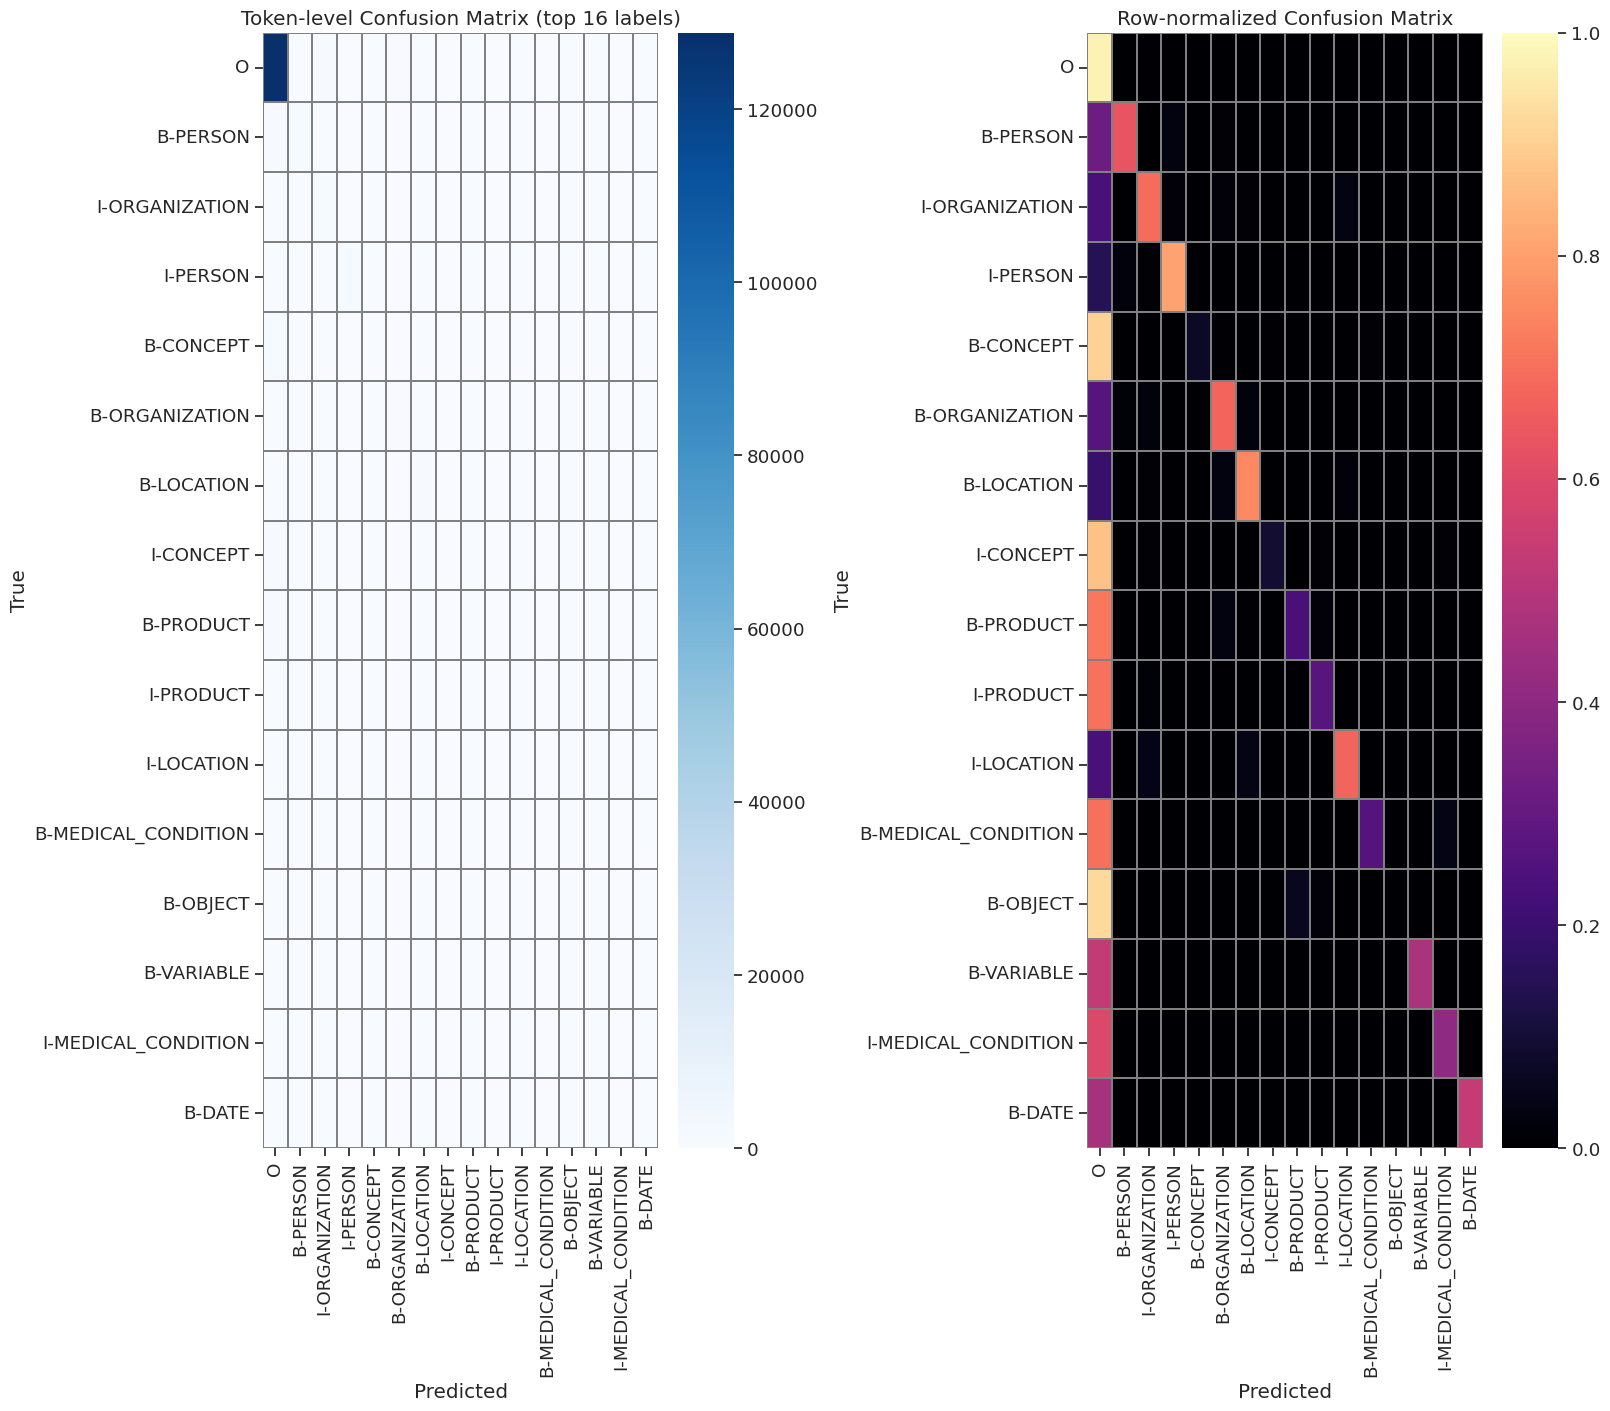


Top label confusions (true -> predicted):
  B-CONCEPT -> O: 1273
  I-CONCEPT -> O: 897
  B-PERSON -> O: 572
  B-PRODUCT -> O: 550
  O -> I-ORGANIZATION: 520
  O -> B-ORGANIZATION: 512
  B-OBJECT -> O: 473
  I-PRODUCT -> O: 471
  O -> B-LOCATION: 387
  I-ORGANIZATION -> O: 371
  B-ORGANIZATION -> O: 362
  B-MEDICAL_CONDITION -> O: 360
  O -> B-PERSON: 349
  O -> I-LOCATION: 271
  I-MEDICAL_CONDITION -> O: 265


In [29]:
import json

eval_results = trainer.evaluate(tokenized_dataset[eval_split])
print('Evaluation results:', eval_results)

pred_output = trainer.predict(tokenized_dataset[eval_split])
pred_ids    = np.argmax(pred_output.predictions, axis=2)
true_ids    = pred_output.label_ids

# ── Flatten valid (non -100) tokens ──────────────────────────────────────────
flat_true, flat_pred = [], []
for pred_seq, true_seq in zip(pred_ids, true_ids):
    for p, t in zip(pred_seq, true_seq):
        if t != -100:
            flat_true.append(int(t))
            flat_pred.append(int(p))

# ── Classification report ─────────────────────────────────────────────────────
target_names = [id2label[i] for i in range(len(label_list))]
report_text  = classification_report(
    flat_true, flat_pred,
    labels=list(range(len(label_list))),
    target_names=target_names,
    zero_division=0, digits=4,
)
report_dict  = classification_report(
    flat_true, flat_pred,
    labels=list(range(len(label_list))),
    target_names=target_names,
    zero_division=0, digits=4, output_dict=True,
)
print(report_text)

# Save reports to EVAL_OUTPUT_DIR 
os.makedirs(EVAL_OUTPUT_DIR, exist_ok=True)
with open(os.path.join(EVAL_OUTPUT_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report_text)
with open(os.path.join(EVAL_OUTPUT_DIR, 'classification_report.json'), 'w') as f:
    json.dump(report_dict, f, indent=2)
print(f'Reports saved to {EVAL_OUTPUT_DIR}')

# ── Confusion matrix  ────────────────────────
all_label_ids  = list(range(len(label_list)))
all_cm         = confusion_matrix(flat_true, flat_pred, labels=all_label_ids)
label_support  = all_cm.sum(axis=1)
o_id           = label2id.get('O', None)

entity_ids     = sorted(
    [i for i in all_label_ids if i != o_id and label_support[i] > 0],
    key=lambda i: label_support[i], reverse=True,
)
selected_ids   = entity_ids[:TOP_K_CONFUSION]
if o_id is not None and label_support[o_id] > 0:
    selected_ids = [o_id] + selected_ids
if not selected_ids:
    selected_ids = [i for i in all_label_ids if label_support[i] > 0][:TOP_K_CONFUSION]

cm             = confusion_matrix(flat_true, flat_pred, labels=selected_ids)
selected_names = [id2label[i] for i in selected_ids]
row_sums       = cm.sum(axis=1, keepdims=True)
cm_norm        = np.divide(cm, row_sums, where=row_sums != 0)

fig_w = max(12, min(24, int(0.5 * len(selected_names)) + 8))
fig_h = max(8,  min(20, int(0.5 * len(selected_names)) + 6))
fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), constrained_layout=True)

sns.heatmap(cm,      ax=axes[0], cmap='Blues', xticklabels=selected_names, yticklabels=selected_names, linewidths=0.2, linecolor='gray')
axes[0].set_title(f'Token-level Confusion Matrix (top {len(selected_names)} labels)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=90)

sns.heatmap(cm_norm, ax=axes[1], cmap='magma', vmin=0, vmax=1, xticklabels=selected_names, yticklabels=selected_names, linewidths=0.2, linecolor='gray')
axes[1].set_title('Row-normalized Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=90)

plt.savefig(os.path.join(EVAL_OUTPUT_DIR, 'confusion_matrices.png'), dpi=150)
plt.show()

pair_errors = sorted(
    [(cm[i, j], selected_names[i], selected_names[j])
     for i in range(cm.shape[0]) for j in range(cm.shape[1]) if i != j and cm[i, j] > 0],
    reverse=True,
)
print('\nTop label confusions (true -> predicted):')
for count, true_name, pred_name in pair_errors[:15]:
    print(f'  {true_name} -> {pred_name}: {int(count)}')

if ENABLE_WANDB and wandb.run is not None:
    wandb.log({f'final/{k}': v for k, v in eval_results.items() if isinstance(v, (int, float))})
    wandb.log({'confusion_matrix': wandb.Image(os.path.join(EVAL_OUTPUT_DIR, 'confusion_matrices.png'))})


## 6. Save model and optional push to Hugging Face Hub

Save locally first, then push only when `HF_TOKEN` is available in environment variables.

In [30]:
trainer.save_model(LOCAL_MODEL_DIR)
tokenizer.save_pretrained(LOCAL_MODEL_DIR)
print(f'Model/tokenizer saved to: {LOCAL_MODEL_DIR}')

if HF_TOKEN:
    trainer.model.push_to_hub(HF_REPO, token=HF_TOKEN)
    tokenizer.push_to_hub(HF_REPO, token=HF_TOKEN)
    hf_url = f'https://huggingface.co/{HF_REPO}'
    print(f'Pushed to Hugging Face Hub: {hf_url}')
    if ENABLE_WANDB and wandb.run is not None:
        wandb.run.summary['huggingface_model'] = hf_url
else:
    print('HF_TOKEN not set – skipping push_to_hub.')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model/tokenizer saved to: ./models/dslim-bert-base-NER


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Pushed to Hugging Face Hub: https://huggingface.co/anuragvishwakarma02/mlops-group23-ner


In [31]:
# ── Word-level prediction analysis ──────
raw_eval = dataset[eval_split]

def build_word_level_triplets(example_tokens, tokenized_inputs, pred_seq, true_seq):
    word_ids = tokenized_inputs.word_ids()
    triplets, prev_word = [], None
    for pos, word_id in enumerate(word_ids):
        if word_id is None or word_id == prev_word:
            prev_word = word_id
            continue
        true_id = true_seq[pos]
        pred_id = pred_seq[pos]
        if true_id != -100 and word_id < len(example_tokens):
            triplets.append((
                example_tokens[word_id],
                label_list[true_id],
                label_list[pred_id],
            ))
        prev_word = word_id
    return triplets

sample_n = min(5, len(raw_eval))
for i in range(sample_n):
    tokens     = raw_eval[i][token_col]
    tok_inputs = tokenizer(tokens, truncation=True, is_split_into_words=True, max_length=MAX_LENGTH)
    triplets   = build_word_level_triplets(tokens, tok_inputs, pred_ids[i], true_ids[i])
    print(f'\nExample {i + 1}')
    print('-' * 55)
    for token, true_tag, pred_tag in triplets[:40]:
        status = 'OK' if true_tag == pred_tag else 'ERR'
        print(f'{token:16s}  true={true_tag:12s}  pred={pred_tag:12s}  {status}')

if ENABLE_WANDB and wandb.run is not None:
    wandb.finish()
    print('W&B run finished.')



Example 1
-------------------------------------------------------
500               true=O             pred=O             OK
Payday            true=O             pred=O             OK
Loan              true=O             pred=O             OK
in                true=O             pred=O             OK
Gretna            true=B-LOCATION    pred=B-LOCATION    OK
Louisiana         true=B-LOCATION    pred=B-LOCATION    OK
Gretna            true=B-LOCATION    pred=B-LOCATION    OK
500               true=O             pred=O             OK
Payday            true=O             pred=O             OK
Loan              true=O             pred=O             OK
Short             true=O             pred=O             OK
term              true=O             pred=O             OK
loan              true=O             pred=O             OK
or                true=O             pred=O             OK
payday            true=O             pred=O             OK
loan              true=O             pred=O     

eval/accuracy,▁▆██
eval/f1,▁▇██
eval/loss,█▃▁▁
eval/precision,█▁██
eval/recall,▁███
eval/runtime,▄▅▁█
eval/samples_per_second,▅▄█▁
eval/steps_per_second,▅▃█▁
final/epoch,▁
final/eval_accuracy,▁
+20,...


W&B run finished.


In [32]:
import json as _json

# ── Inference
def predict_ner_tags(text, tokenizer_obj, model_obj, id2label_map):
    words   = text.split()
    encoded = tokenizer_obj(
        words, is_split_into_words=True,
        return_tensors='pt', truncation=True, max_length=MAX_LENGTH,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        outputs  = model_obj(**encoded)
        pred_ids_ = torch.argmax(outputs.logits, dim=-1)[0].cpu().tolist()

    word_ids_  = tokenizer_obj(
        words, is_split_into_words=True, truncation=True, max_length=MAX_LENGTH,
    ).word_ids()

    token_labels, prev_word = [], None
    for pos, word_id in enumerate(word_ids_):
        if word_id is None or word_id == prev_word:
            prev_word = word_id
            continue
        label_id = pred_ids_[pos]
        label    = id2label_map.get(label_id, str(label_id))
        token_labels.append({'token': words[word_id], 'label': label})
        prev_word = word_id

    entities = [r for r in token_labels if r['label'] != 'O']
    return token_labels, entities

# Reuse in-memory model/tokenizer if available; otherwise load from saved dir.
try:
    infer_model     = model
    infer_tokenizer = tokenizer
    infer_id2label  = id2label
except NameError:
    infer_tokenizer = AutoTokenizer.from_pretrained(LOCAL_MODEL_DIR)
    infer_model     = AutoModelForTokenClassification.from_pretrained(LOCAL_MODEL_DIR).to(device)
    infer_id2label  = {int(k): v for k, v in infer_model.config.id2label.items()}

infer_model.eval()

custom_sentences = [
    'Google launched a new model with 12B parameters in California.',
    'Satya Nadella is the CEO of Microsoft.',
    'I live in Pune and work for EY.',
]

print('=' * 60)
print('NER INFERENCE RESULTS')
print('=' * 60)
for idx, text in enumerate(custom_sentences, start=1):
    token_labels, entities = predict_ner_tags(text, infer_tokenizer, infer_model, infer_id2label)
    result = {
        'sentence':     text,
        'token_labels': token_labels,
        'entities':     entities,
    }
    print(f'\nSentence {idx}: {text}')
    print('Token-level tags:')
    for row in token_labels:
        print(f"  {row['token']:16s} -> {row['label']}")
    if entities:
        print('Named entities:')
        for row in entities:
            print(f"  {row['token']} ({row['label']})")
    else:
        print('Named entities: none detected')


NER INFERENCE RESULTS

Sentence 1: Google launched a new model with 12B parameters in California.
Token-level tags:
  Google           -> B-ORGANIZATION
  launched         -> O
  a                -> O
  new              -> O
  model            -> O
  with             -> O
  12B              -> O
  parameters       -> O
  in               -> O
  California.      -> B-LOCATION
Named entities:
  Google (B-ORGANIZATION)
  California. (B-LOCATION)

Sentence 2: Satya Nadella is the CEO of Microsoft.
Token-level tags:
  Satya            -> B-PERSON
  Nadella          -> I-PERSON
  is               -> O
  the              -> O
  CEO              -> O
  of               -> O
  Microsoft.       -> B-ORGANIZATION
Named entities:
  Satya (B-PERSON)
  Nadella (I-PERSON)
  Microsoft. (B-ORGANIZATION)

Sentence 3: I live in Pune and work for EY.
Token-level tags:
  I                -> O
  live             -> O
  in               -> O
  Pune             -> B-LOCATION
  and              -> O
  work    